In [ ]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "geopandas",
#     "lonboard",
#     "matplotlib",
#     "palettable",
#     "pyarrow",
#     "pyogrio",
# ]
# ///

# North America Roads

This example uses data from [Natural Earth](https://www.naturalearthdata.com/) to plot the road network in North America. Refer to the [data documentation](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/roads/) for more information about this dataset.

You can view a [hosted version of this notebook on Notebook Sharing Space](https://notebooksharing.space/view/8fcb718843e480c7a3bb0065155466103984f41225d66aa9b25790363a346531#displayOptions=) (6MB download).


## Dependencies

Install [`uv`](https://docs.astral.sh/uv) and then launch this notebook with:

```
uvx juv run examples/north-america-roads.ipynb
```

(The `uvx` command is included when installing `uv`).


## Imports


In [1]:
import geopandas as gpd
import palettable.colorbrewer.diverging

from lonboard import Map, PathLayer
from lonboard.colormap import apply_continuous_cmap

The "public" URL for this dataset from the Natural Earth website is

```
https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/10m/cultural/ne_10m_roads_north_america.zip
```

That doesn't appear to work directly inside a notebook, so we'll use the URL the above redirects to:

```
https://naciscdn.org/naturalearth/10m/cultural/ne_10m_roads_north_america.zip
```

It's possible this "private" URL will change in the future.


In [2]:
url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_roads_north_america.zip"

We'll use GeoPandas to fetch this data (45MB) over the internet and load it into a `GeoDataFrame`. This uses the [`pyogrio` engine](https://geopandas.org/en/stable/docs/reference/api/geopandas.read_file.html), which is faster. Ensure you have [`pyogrio`](https://github.com/geopandas/pyogrio) installed.


In [26]:
gdf = gpd.read_file(url, engine="pyogrio")

This dataframe has a variety of attributes, plus a geometry column with a `LineString` type.


In [25]:
gdf.head(10)

,prefix,number,class,type,divided,country,state,note,scalerank,uident,length,rank,continent,geometry
671,NaN,NaN,U/C,Freeway,Divided,United States,Alabama,NaN,7,671,8.938030,2,North America,"LINESTRING (-86.88528 33.59536, -86.88092 33.5..."
672,NaN,NaN,State,Freeway,Divided,United States,Alabama,NaN,8,672,0.214712,0,North America,"LINESTRING (-86.67144 34.7068, -86.67163 34.70..."
673,NaN,255,State,Freeway,Divided,United States,Alabama,NaN,10,673,9.523340,-1,North America,"LINESTRING (-86.67144 34.7068, -86.67144 34.70..."
674,US,78,Federal,Freeway,Divided,United States,Alabama,NaN,6,674,164.203000,2,North America,"LINESTRING (-88.07006 34.17647, -88.06625 34.1..."
675,US,231,Federal,Freeway,Divided,United States,Alabama,NaN,8,675,2.973830,2,North America,"LINESTRING (-86.59265 34.7201, -86.59448 34.72..."
676,US,31,Federal,Freeway,Divided,United States,Alabama,NaN,9,676,6.370230,0,North America,"LINESTRING (-86.78706 33.48426, -86.78703 33.4..."
677,US,4,Federal,Freeway,Divided,United States,Alabama,NaN,8,677,2.068200,0,North America,"LINESTRING (-88.08693 34.18263, -88.07647 34.1..."
678,US,78,Federal,Freeway,Divided,United States,Alabama,NaN,6,678,11.827700,2,North America,"LINESTRING (-88.18732 34.21076, -88.18725 34.2..."
679,US,80,Federal,Freeway,Divided,United States,Alabama,NaN,8,679,1.469870,0,North America,"LINESTRING (-86.3496 32.31335, -86.3496 32.313..."
680,US,80,Federal,Freeway,Divided,United States,Alabama,NaN,7,680,4.595880,0,North America,"LINESTRING (-85.03349 32.48891, -85.03008 32.4..."


In [14]:
gdf['type'].unique()

<ArrowStringArray>
[    'Unpaved', 'Other Paved',   'Secondary',     'Primary',     'Freeway',
       'Ferry',      'Winter',     'Tollway',       'Trail',       'Paved']
Length: 10, dtype: str

In [27]:
# gdf = gdf[gdf['type']=='Freeway']
# gdf = gdf[gdf['type'].isin(['Freeway', 'Tollway'])]
gdf = gdf[(gdf['type'].isin(['Freeway', 'Tollway'])) & (gdf['country'] == 'United States')]

To ensure that this demo is snappy on most computers, we'll filter to only the contiguous U.S. If you're on a recent computer, feel free to comment out this line.


In [ ]:
# gdf_ =

In [ ]:
# gdf = gdf[gdf["state"] == "California"]

To render `LineString` data, first create a `PathLayer` and then add it to a `Map` object.


In [28]:
layer = PathLayer.from_geopandas(gdf, width_min_pixels=0.8)
map_ = Map(layer)
map_

We can look at the [documentation for `PathLayer`](https://developmentseed.org/lonboard/latest/api/layers/path-layer/) to see what other rendering options it allows. Let's set the path color to something other than black:


In [29]:
layer.get_color = [200, 0, 200]

Ok, so we can see the data! That's great! But let's customize the rendering based on an attribute!

The `scalerank` column tells how important the road is in the road network. Let's see what the distribution of values is for this column:


In [30]:
gdf["scalerank"].value_counts().sort_index()

scalerank
3     238
4     256
5     273
6     224
7     508
8     721
9      74
10    332
11      7
Name: count, dtype: int64

Ok, so the values range from `3` to `12`. To assign a colormap to this column, we need "normalized" values that span between 0 and 1:


In [31]:
normalized_scale_rank = (gdf["scalerank"] - 3) / 9

The values of this array now range from 0 to 1:


In [32]:
normalized_scale_rank.min(), normalized_scale_rank.max()

(np.float64(0.0), np.float64(0.8888888888888888))

Let's select a colormap to apply to this data:


In [33]:
cmap = palettable.colorbrewer.diverging.PuOr_10

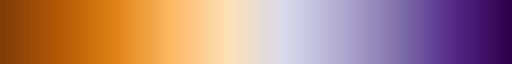

In [34]:
cmap.mpl_colormap

Now we'll use `apply_continuous_cmap` onto this array to generate colors for our data. Just set this new array onto the existing layer, and you'll see the map update with the new colors!


In [35]:
layer.get_color = apply_continuous_cmap(
    normalized_scale_rank,
    palettable.colorbrewer.diverging.PuOr_10,
    alpha=0.8,
)

In [40]:
import duckdb
gdf_arrow = gdf.to_arrow()
con = duckdb.connect()
con.sql("install spatial; load spatial; install h3 from community; load h3")
# con.sql("CALL register_geoarrow_extensions()")
con.sql("select * from gdf_arrow")

┌─────────┬─────────┬────────────┬─────────┬─────────┬───────────────┬────────────────┬─────────┬───────────┬────────┬──────────┬───────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────